<a href="https://colab.research.google.com/github/DiegoAbarza77/Mineria_de_Datos/blob/desarrollo-proyecto-Ignacio/Copia_de_Evaluacion1_Mineria_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primer entrega de Mineria de datos

Integrantes:
Ignacio Rivera


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns


In [19]:
df = pd.read_csv("/Smartphone_Usage_And_Addiction.csv")

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
df.shape

(7500, 16)

In [22]:
df.head(100)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN00096,U00096,31,Male,10.81,4.47,3.87,3.80,6.08,167,144,11.84,High,No,Moderate,1
96,TXN00097,U00097,29,Male,10.61,2.52,3.05,3.66,8.13,236,158,13.55,High,Yes,Severe,1
97,TXN00098,U00098,23,Male,5.46,4.69,3.69,2.43,5.32,56,159,7.60,Low,Yes,Moderate,1
98,TXN00099,U00099,34,Other,4.94,2.81,1.36,2.54,7.75,218,160,6.93,Low,Yes,NaN,0


In [23]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [24]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 819
Total de valores nulos de addicted_label = 0


In [25]:
#hay que ver como se resuele los valores nulos en este caso

In [26]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


# Realizaremos un mapeo de datos


'transaction_id'

'user_id'

'age'

'gender'

'daily_screen_time_hours'

'social_media_hours'

'gaming_hours'

'work_study_hours'

'sleep_hours'

'notifications_per_day'

'app_opens_per_day'

'weekend_screen_time'

'stress_level'

'academic_work_impact'

'addiction_level'

'addicted_label'

# Clasificacion de Variables
Categorico Nominal: Categorias sin un orden o jerarquia especifica.
Ejemplo: Region, Comuna, Genero.

Categorico Ordinal: Categorias que siguen un orden logico o escala.
Ejemplo: Nivel educacional (Basica, Media, Superior).

Numerico Discreto: Valores que surgen de un conteo y no admiten decimales.
Ejemplo: Cantidad de personas, Numero de hijos.

Numerico Continuo: Valores que resultan de una medicion y pueden tener decimales infinitos.
Ejemplo: Estatura, Peso, Temperatura.

In [27]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [28]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


In [29]:
"""
#utilizaremos expresiones regulares para eliminar los puntos
cols_a_convertir = [
    "gender", "stress_level", "academic_work_impact", "addicted_label"
]

for col in cols_a_convertir:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('.', '', regex=False), errors='coerce')"""

'\n#utilizaremos expresiones regulares para eliminar los puntos\ncols_a_convertir = [\n    "gender", "stress_level", "academic_work_impact", "addicted_label"\n]\n\nfor col in cols_a_convertir:\n    if col in df.columns:\n        df[col] = pd.to_numeric(df[col].astype(str).str.replace(\'.\', \'\', regex=False), errors=\'coerce\')'

In [30]:
ctext = ['addiction_level']

for columna in ctext:
    mode = df[columna].mode()[0]
    df[columna] = df[columna].fillna(mode)

In [31]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 0
Total de valores nulos de addicted_label = 0


In [32]:
df.head(100)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Moderate,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Moderate,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN00096,U00096,31,Male,10.81,4.47,3.87,3.80,6.08,167,144,11.84,High,No,Moderate,1
96,TXN00097,U00097,29,Male,10.61,2.52,3.05,3.66,8.13,236,158,13.55,High,Yes,Severe,1
97,TXN00098,U00098,23,Male,5.46,4.69,3.69,2.43,5.32,56,159,7.60,Low,Yes,Moderate,1
98,TXN00099,U00099,34,Other,4.94,2.81,1.36,2.54,7.75,218,160,6.93,Low,Yes,Moderate,0


In [33]:
df.shape


(7500, 16)

In [34]:
porcentaje_adictos = (df[df['addicted_label'] == 1].shape[0] / df.shape[0]) * 100
print(f"El porcentaje de personas adictas es: {porcentaje_adictos:.2f}%")

El porcentaje de personas adictas es: 70.77%


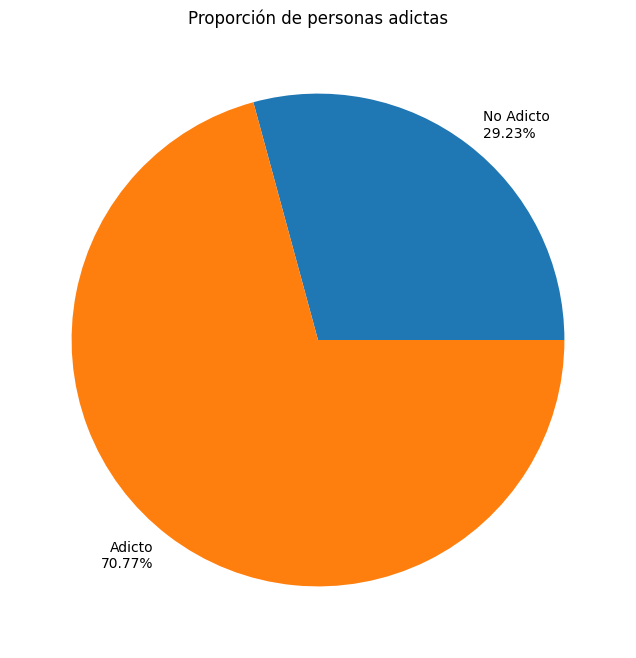

In [35]:


#tenemos el conteo de los adictos
addiction_counts = df.groupby('addicted_label').size()

# ahora calculamos el porcentaje de los NO adictos en donde vamos a descontarle el porcentaje de los Adictos que calculamos
no_addicted_percent = 100 - porcentaje_adictos

labels = []
labels.append(f'No Adicto\n{no_addicted_percent:.2f}%')
labels.append(f'Adicto\n{porcentaje_adictos:.2f}%')

plt.figure(figsize=(8, 8))
plt.pie(addiction_counts, labels=labels, autopct='')
plt.title('Proporción de personas adictas')
plt.show()

In [36]:
# Esto te dirá el promedio de cada variable para adictos vs no adictos
print(df.groupby('addicted_label').mean(numeric_only=True))

                      age  daily_screen_time_hours  social_media_hours  \
addicted_label                                                           
0               26.534672                 5.156861            2.251615   
1               26.582894                 8.467502            3.695477   

                gaming_hours  work_study_hours  sleep_hours  \
addicted_label                                                
0                   1.999051          3.239672     6.666665   
1                   2.020431          3.243555     6.766839   

                notifications_per_day  app_opens_per_day  weekend_screen_time  
addicted_label                                                                 
0                          134.325730          97.000456             6.894535  
1                          134.229088          98.175961            10.213994  


In [37]:
# Ver la relación entre la etiqueta y otras columnas numéricas
df.select_dtypes(include=np.number).corr()['addicted_label'].sort_values(ascending=False)

,addicted_label
addicted_label,1.000000
daily_screen_time_hours,0.577112
weekend_screen_time,0.555426
social_media_hours,0.414244
sleep_hours,0.035496
app_opens_per_day,0.011041
gaming_hours,0.008485
age,0.004220
work_study_hours,0.001103
notifications_per_day,-0.000660


In [38]:
crosstab_result = pd.crosstab(df['addiction_level'], df['addicted_label'])
display(crosstab_result)

addicted_label,0,1
addiction_level,,
Mild,1373,0
Moderate,819,2874
Severe,0,2434


In [39]:
moderate_df = df[df['addiction_level'] == 'Moderate']
print("Comparación de promedios dentro del nivel 'Moderate' según 'addicted_label':")
display(moderate_df.groupby('addicted_label').mean(numeric_only=True))

Comparación de promedios dentro del nivel 'Moderate' según 'addicted_label':


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,,
0,26.472527,4.522833,2.240696,2.006081,3.259536,6.677582,134.363858,97.107448,6.227790
1,26.433194,8.351427,3.579694,2.033135,3.240438,6.756816,135.382394,97.955811,10.090647


ACA SE PUEDE VER LAS DIFERENCIAS QUE EXISTEN EN LA CATEGORIA MODERATE EN DONDE SE PUEDE VER POR QUE ALGUNOS MODERATE ENTRAN EN ADICTOS Y CUALES NO


/tmp/ipykernel_4570/1098830713.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='addicted_label', y='daily_screen_time_hours', data=average_daily_screen_time, palette='viridis')


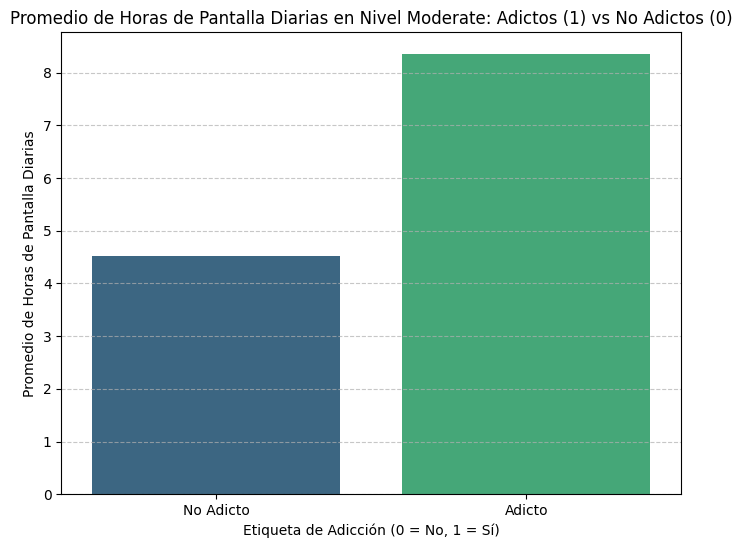

In [40]:


# Filtrar solo el grupo Moderate (ya definido anteriormente)
moderate_group = df[df['addiction_level'] == 'Moderate']

# Calcular el promedio de daily_screen_time_hours para cada addicted_label en el grupo moderate
average_daily_screen_time = moderate_group.groupby('addicted_label')['daily_screen_time_hours'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='addicted_label', y='daily_screen_time_hours', data=average_daily_screen_time, palette='viridis')

plt.title('Promedio de Horas de Pantalla Diarias en Nivel Moderate: Adictos (1) vs No Adictos (0)')
plt.xlabel('Etiqueta de Adicción (0 = No, 1 = Sí)')
plt.ylabel('Promedio de Horas de Pantalla Diarias')
plt.xticks([0, 1], ['No Adicto', 'Adicto']) # Personalizar etiquetas del eje X
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_4570/4171730103.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age', y='count_of_addicted', data=addiction_by_age, palette='magma')


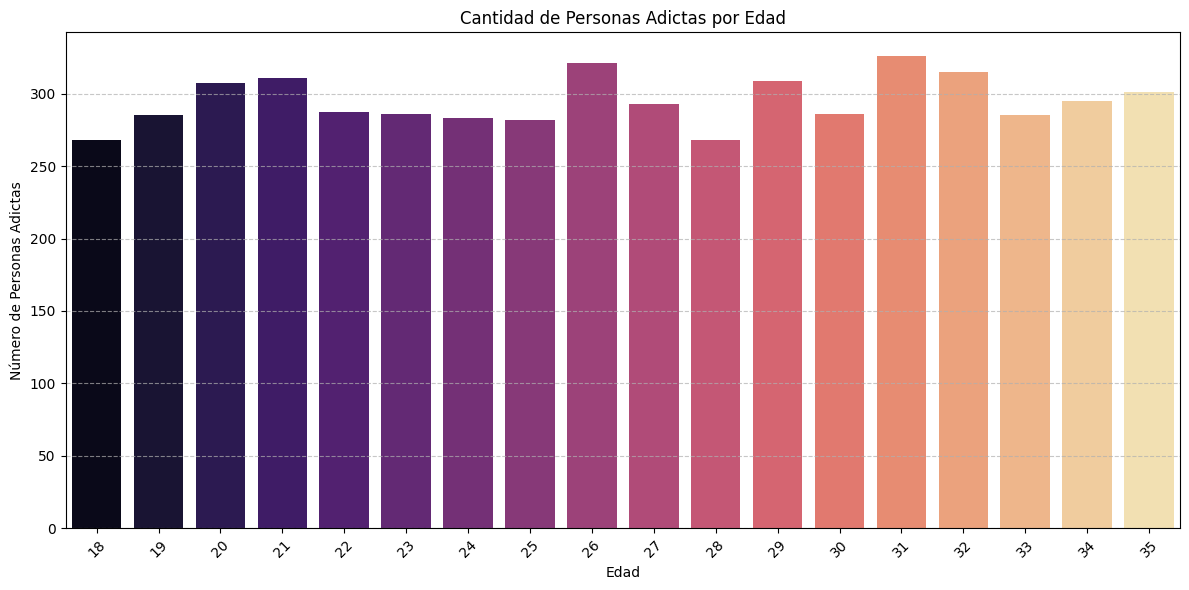

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para obtener solo a las personas adictas
addicted_people = df[df['addicted_label'] == 1]

# Contar la cantidad de personas adictas por edad
addiction_by_age = addicted_people['age'].value_counts().sort_index().reset_index()
addiction_by_age.columns = ['age', 'count_of_addicted']

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x='age', y='count_of_addicted', data=addiction_by_age, palette='magma')

plt.title('Cantidad de Personas Adictas por Edad')
plt.xlabel('Edad')
plt.ylabel('Número de Personas Adictas')
plt.xticks(rotation=45) # Rotar etiquetas para mejor legibilidad si hay muchas edades
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

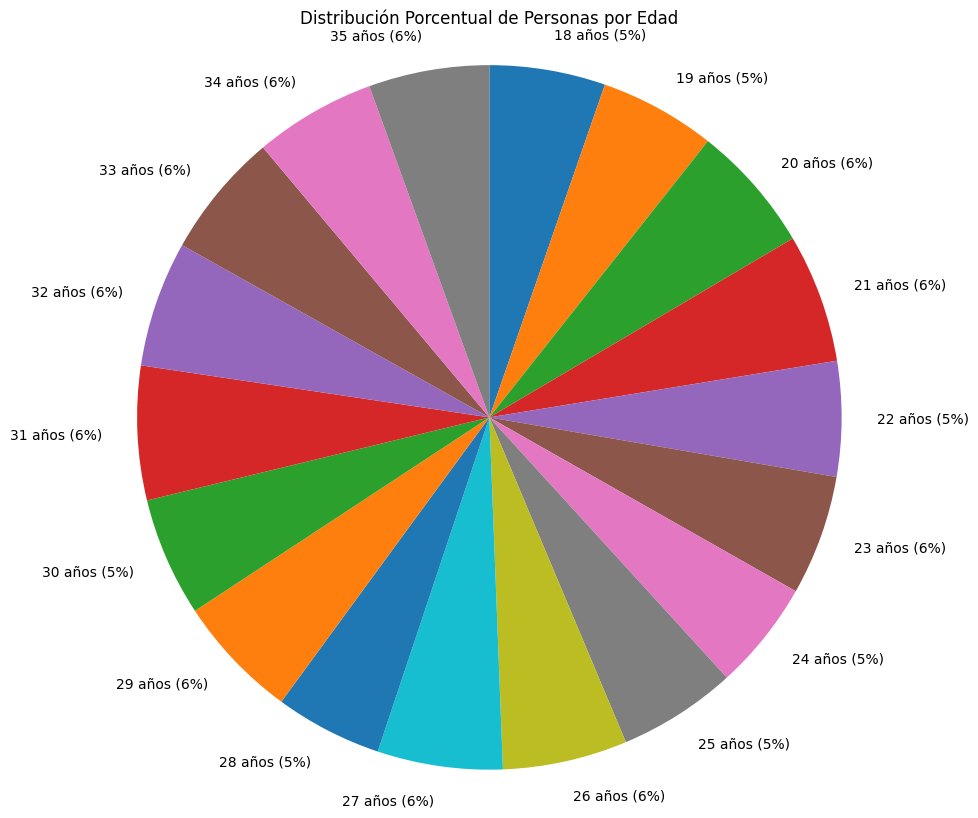

In [47]:
import matplotlib.pyplot as plt

# Calcular el conteo de cada edad
age_counts = df['age'].value_counts().sort_index()

# Calcular los porcentajes
age_percentages = age_counts / age_counts.sum() * 100

# Crear las etiquetas para el gráfico de torta incluyendo la edad (como entero) y el porcentaje (sin decimales)
labels = [f'{int(age)} años ({percent:.0f}%)' for age, percent in age_percentages.items()]

plt.figure(figsize=(10, 10))
plt.pie(age_counts, labels=labels, autopct='', startangle=90, counterclock=False)
plt.title('Distribución Porcentual de Personas por Edad')
plt.axis('equal') # Asegura que el círculo sea un círculo.
plt.show()

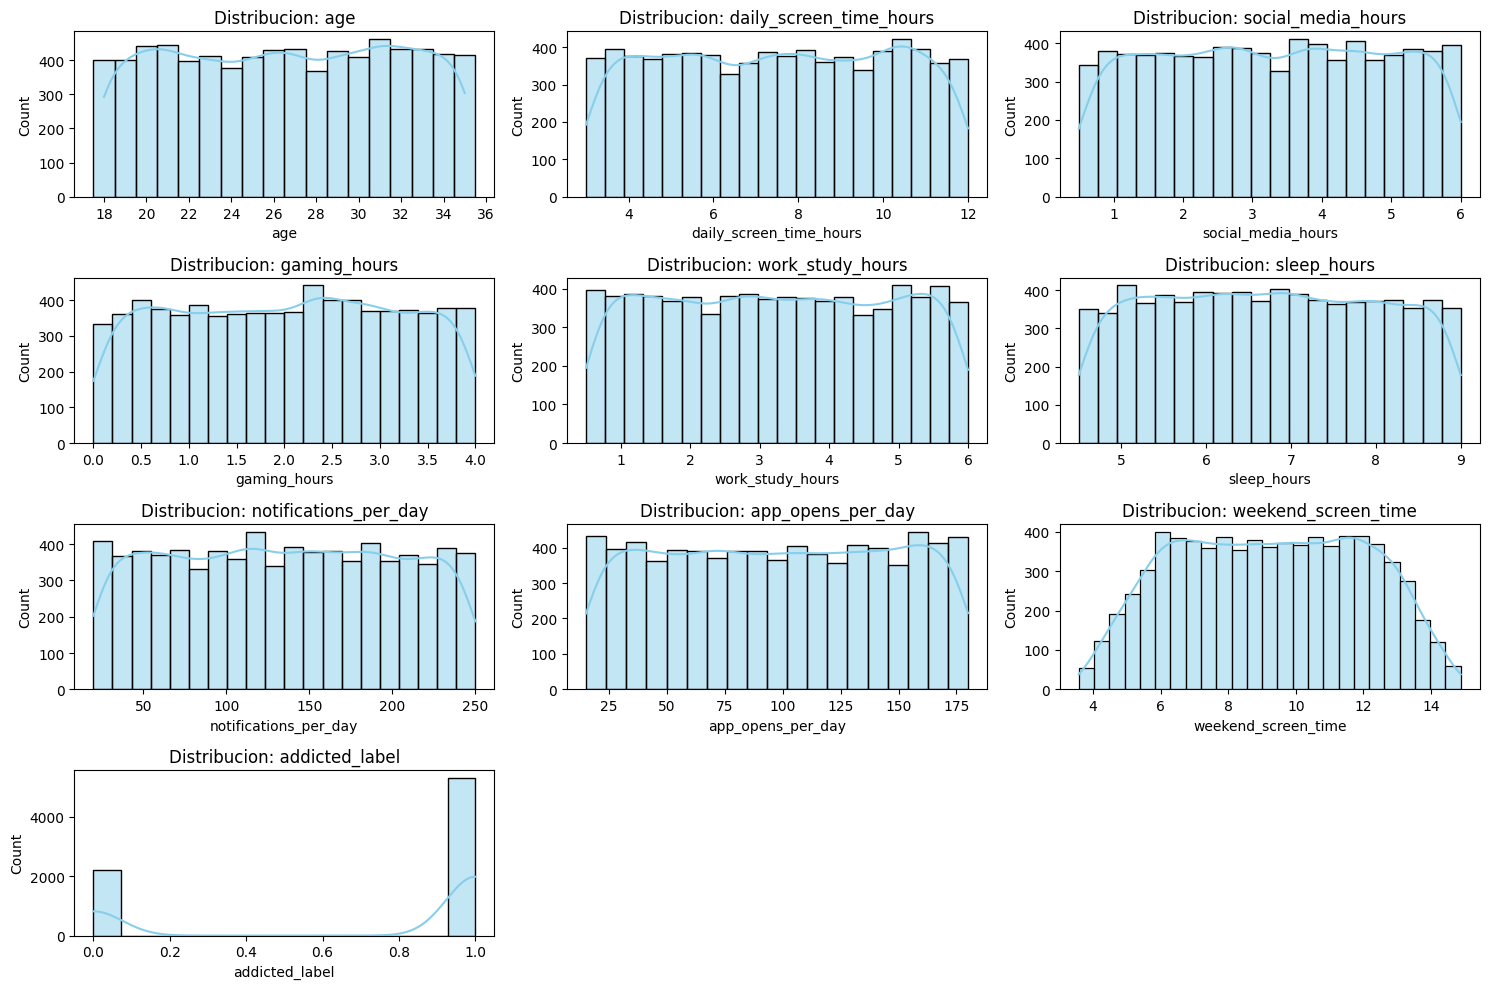

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator  # <-- Agregamos esta importación clave

cols_numericas = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time", "addicted_label",
]

# Configuracion de graficos
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    # Capturamos el "eje" actual (subplot) en la variable 'ax'
    ax = plt.subplot(4, 3, i)

    if col == 'age':
        sns.histplot(df[col], kde=True, color='skyblue', discrete=True)
        # Forzamos a que las etiquetas del eje X sean solo números enteros
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    else:
        sns.histplot(df[col], kde=True, color='skyblue')

    plt.title(f'Distribucion: {col}')

plt.tight_layout()
plt.show()